# PPG-Based Glucose Estimation

Dataset path: `/Users/ishananand/Desktop/Time-Series/CGM_Dataset`

This notebook prepares the public Mazandaran dataset version 2 for glucose estimation from raw PPG. The dataset contains 67 raw PPG recordings sampled at 2175 Hz from 23 participants. Each recording has one corresponding blood glucose reading.


## 1. Imports and Configuration


In [149]:
import random
import re
from fractions import Fraction
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, resample_poly
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('seaborn-v0_8-whitegrid')

DATASET_PATH = Path('/Users/ishananand/Desktop/Time-Series/CGM_Dataset')
RAW_DATA_PATH = DATASET_PATH / 'RawData'
LABEL_PATH = DATASET_PATH / 'Labels'

RAW_FS = 2175
TARGET_FS = 30
LOWCUT_HZ = 0.5
HIGHCUT_HZ = 8.0
FILTER_ORDER = 4
TARGET_SECONDS = 10
TARGET_LENGTH = TARGET_SECONDS * TARGET_FS

RANDOM_STATE = 42
BATCH_SIZE = 8
EPOCHS = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 25

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Using device:', device)
print('Target processed signal length:', TARGET_LENGTH)


Using device: mps
Target processed signal length: 300


## 2. Load Labels and Raw PPG Files

Each `signal_subject_recording.csv` file is matched to its corresponding `label_subject_recording.csv` file. The model input is only the processed PPG signal, and the output is the glucose value.


In [150]:
def parse_recording_key(path, prefix):
    match = re.search(rf'{prefix}_(\d+)_(\d+)\.csv$', path.name)
    if match is None:
        raise ValueError(f'Unexpected filename: {path.name}')
    subject_id = int(match.group(1))
    recording_id = int(match.group(2))
    recording_key = f'{subject_id:02d}_{recording_id:04d}'
    return subject_id, recording_id, recording_key


def load_raw_signal(path):
    signal = pd.read_csv(path, header=None).iloc[:, 0]
    signal = pd.to_numeric(signal, errors='coerce')
    signal = signal.interpolate(limit_direction='both')
    return signal.to_numpy(dtype='float32')


def load_label(path):
    subject_id, recording_id, recording_key = parse_recording_key(path, 'label')
    label = pd.read_csv(path)
    return {
        'recording_key': recording_key,
        'subject_id': subject_id,
        'recording_id': recording_id,
        'glucose': float(label.loc[0, 'Glucose']),
    }

signal_files = sorted(RAW_DATA_PATH.glob('signal_*.csv'))
label_files = sorted(LABEL_PATH.glob('label_*.csv'))

labels = pd.DataFrame([load_label(path) for path in label_files])

records = []
for signal_path in signal_files:
    subject_id, recording_id, recording_key = parse_recording_key(signal_path, 'signal')
    raw_signal = load_raw_signal(signal_path)
    records.append({
        'recording_key': recording_key,
        'subject_id': subject_id,
        'recording_id': recording_id,
        'raw_signal': raw_signal,
        'raw_length': len(raw_signal),
        'raw_duration_seconds': len(raw_signal) / RAW_FS,
    })

ppg_records = pd.DataFrame(records).merge(
    labels,
    on=['recording_key', 'subject_id', 'recording_id'],
    how='inner',
    validate='one_to_one',
)

print('Signals:', len(signal_files))
print('Labels:', len(label_files))
print('Matched records:', len(ppg_records))
ppg_records[['recording_key', 'subject_id', 'recording_id', 'raw_length', 'raw_duration_seconds', 'glucose']].head()


Signals: 67
Labels: 67
Matched records: 67


,recording_key,subject_id,recording_id,raw_length,raw_duration_seconds,glucose
0,01_0001,1,1,21900,10.068966,99.0
1,01_0002,1,2,21900,10.068966,102.0
2,01_0003,1,3,21900,10.068966,103.0
3,01_0004,1,4,21900,10.068966,128.0
4,01_0005,1,5,21900,10.068966,130.0


## 3. Raw Dataset Inspection


In [151]:
inspection = ppg_records.assign(
    missing_count=lambda df: df['raw_signal'].apply(lambda x: int(np.isnan(x).sum())),
    min_ppg=lambda df: df['raw_signal'].apply(np.nanmin),
    max_ppg=lambda df: df['raw_signal'].apply(np.nanmax),
    amplitude_range=lambda df: df['raw_signal'].apply(lambda x: float(np.nanmax(x) - np.nanmin(x))),
    signal_std=lambda df: df['raw_signal'].apply(np.nanstd),
)

inspection[['raw_length', 'raw_duration_seconds', 'missing_count', 'amplitude_range', 'signal_std', 'glucose']].describe()


,raw_length,raw_duration_seconds,missing_count,amplitude_range,signal_std,glucose
count,67.0,67.000000,67.0,67.000000,67.000000,67.000000
mean,21900.0,10.068966,0.0,32.835821,3.532187,115.014925
std,0.0,0.000000,0.0,10.638120,1.237729,18.736201
min,21900.0,10.068966,0.0,13.000000,1.150789,88.000000
25%,21900.0,10.068966,0.0,26.000000,2.745140,102.500000
50%,21900.0,10.068966,0.0,33.000000,3.495179,110.000000
75%,21900.0,10.068966,0.0,39.500000,4.061856,125.500000
max,21900.0,10.068966,0.0,66.000000,7.761892,183.000000


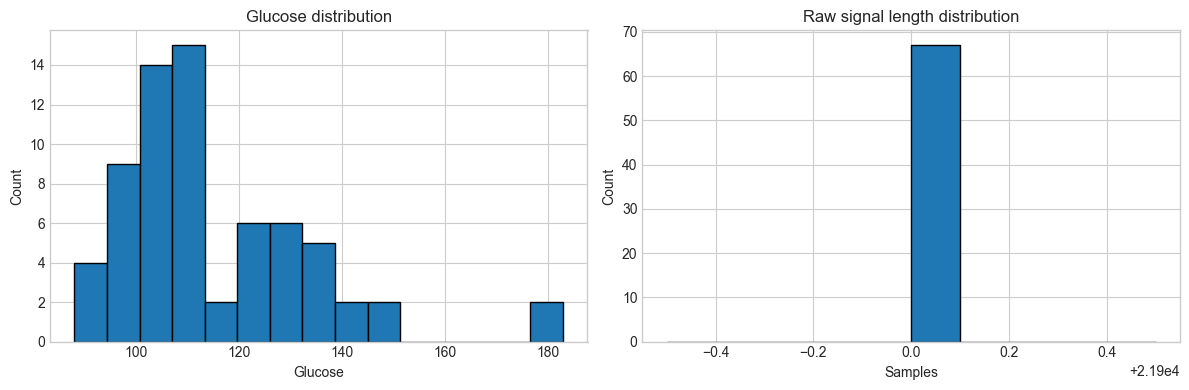

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ppg_records['glucose'], bins=15, edgecolor='black')
axes[0].set_title('Glucose distribution')
axes[0].set_xlabel('Glucose')
axes[0].set_ylabel('Count')

axes[1].hist(ppg_records['raw_length'], bins=10, edgecolor='black')
axes[1].set_title('Raw signal length distribution')
axes[1].set_xlabel('Samples')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


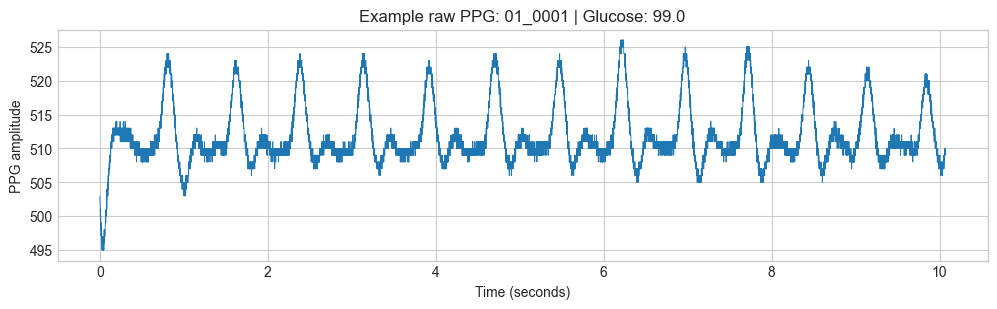

In [153]:
example = ppg_records.iloc[0]
raw_time = np.arange(example['raw_length']) / RAW_FS

plt.figure(figsize=(12, 3))
plt.plot(raw_time, example['raw_signal'], linewidth=0.6)
plt.title(f"Example raw PPG: {example['recording_key']} | Glucose: {example['glucose']}")
plt.xlabel('Time (seconds)')
plt.ylabel('PPG amplitude')
plt.show()


## 4. Band-Pass Filtering

A Butterworth band-pass filter keeps the 0.5 Hz to 8 Hz range. This removes slow baseline drift and high-frequency noise while keeping the useful pulse-frequency range.


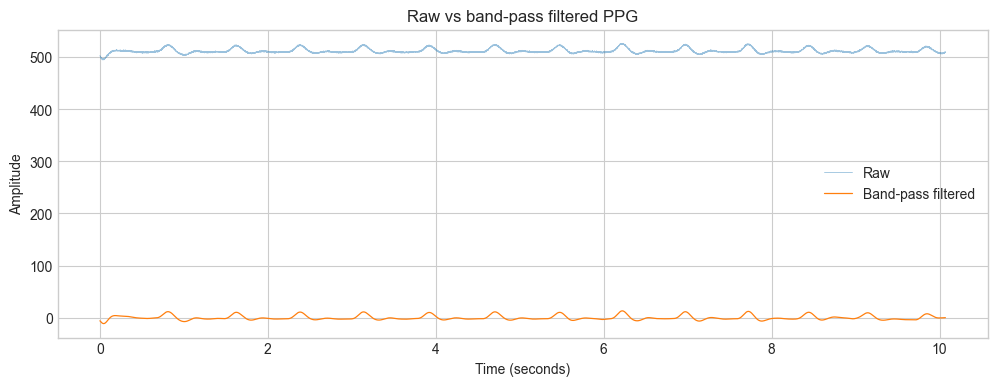

In [154]:
def bandpass_filter_ppg(signal, fs=RAW_FS, lowcut=LOWCUT_HZ, highcut=HIGHCUT_HZ, order=FILTER_ORDER):
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, signal).astype('float32')

ppg_records['filtered_signal'] = ppg_records['raw_signal'].apply(bandpass_filter_ppg)

example = ppg_records.iloc[0]
time = np.arange(example['raw_length']) / RAW_FS

plt.figure(figsize=(12, 4))
plt.plot(time, example['raw_signal'], alpha=0.45, linewidth=0.6, label='Raw')
plt.plot(time, example['filtered_signal'], linewidth=0.9, label='Band-pass filtered')
plt.title('Raw vs band-pass filtered PPG')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


## 5. Downsampling to 30 Hz

After filtering, the signal is downsampled from 2175 Hz to 30 Hz. Since the filtered signal contains components below 8 Hz, 30 Hz is sufficient according to the Nyquist principle.


In [155]:
def downsample_signal(signal, original_fs=RAW_FS, target_fs=TARGET_FS):
    ratio = Fraction(target_fs, original_fs).limit_denominator()
    return resample_poly(signal, ratio.numerator, ratio.denominator).astype('float32')


def fix_signal_length(signal, target_length=TARGET_LENGTH):
    if len(signal) > target_length:
        start = (len(signal) - target_length) // 2
        return signal[start:start + target_length].astype('float32')
    if len(signal) < target_length:
        pad_total = target_length - len(signal)
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        return np.pad(signal, (pad_left, pad_right), mode='edge').astype('float32')
    return signal.astype('float32')

ppg_records['downsampled_signal'] = ppg_records['filtered_signal'].apply(downsample_signal)
ppg_records['processed_signal'] = ppg_records['downsampled_signal'].apply(fix_signal_length)
ppg_records['downsampled_length'] = ppg_records['downsampled_signal'].apply(len)
ppg_records['processed_length'] = ppg_records['processed_signal'].apply(len)

ppg_records[['recording_key', 'downsampled_length', 'processed_length', 'glucose']].head()


,recording_key,downsampled_length,processed_length,glucose
0,01_0001,303,300,99.0
1,01_0002,303,300,102.0
2,01_0003,303,300,103.0
3,01_0004,303,300,128.0
4,01_0005,303,300,130.0


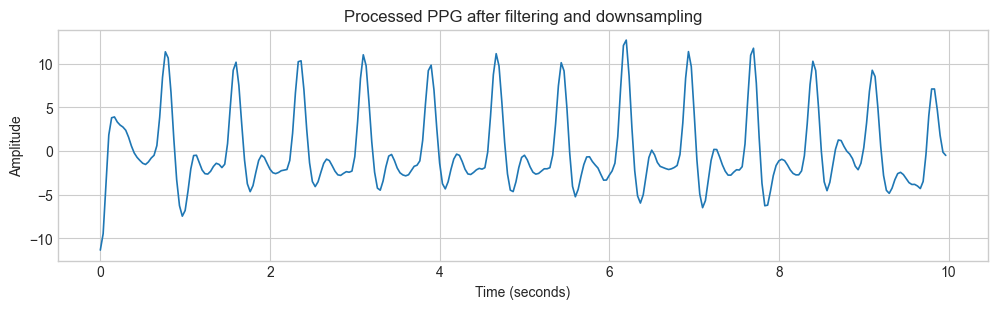

In [156]:
example = ppg_records.iloc[0]
downsampled_time = np.arange(len(example['processed_signal'])) / TARGET_FS

plt.figure(figsize=(12, 3))
plt.plot(downsampled_time, example['processed_signal'], linewidth=1.2)
plt.title('Processed PPG after filtering and downsampling')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()


## 6. Split Original Dataset by Subject

The original 67 recordings are split into training, validation, and test sets by participant ID. This keeps recordings from the same participant out of multiple splits and gives a stricter estimate of generalization.


In [157]:
X_original = np.stack(ppg_records['processed_signal'].to_numpy()).astype('float32')
y_original = ppg_records['glucose'].to_numpy(dtype='float32')
groups = ppg_records['subject_id'].to_numpy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(splitter.split(X_original, y_original, groups=groups))

X_train_val = X_original[train_val_idx]
y_train_val = y_original[train_val_idx]
groups_train_val = groups[train_val_idx]

X_test_raw = X_original[test_idx]
y_test = y_original[test_idx]
groups_test = groups[test_idx]

val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, val_idx = next(val_splitter.split(X_train_val, y_train_val, groups=groups_train_val))

X_train_raw = X_train_val[train_idx]
y_train = y_train_val[train_idx]
groups_train = groups_train_val[train_idx]

X_val_raw = X_train_val[val_idx]
y_val = y_train_val[val_idx]
groups_val = groups_train_val[val_idx]

print('Original records:', len(X_original))
print('Train:', X_train_raw.shape, 'subjects:', len(np.unique(groups_train)))
print('Validation:', X_val_raw.shape, 'subjects:', len(np.unique(groups_val)))
print('Test:', X_test_raw.shape, 'subjects:', len(np.unique(groups_test)))
print('Train/Test subject overlap:', sorted(set(groups_train) & set(groups_test)))
print('Validation/Test subject overlap:', sorted(set(groups_val) & set(groups_test)))


Original records: 67
Train: (34, 300) subjects: 13
Validation: (16, 300) subjects: 5
Test: (17, 300) subjects: 5
Train/Test subject overlap: []
Validation/Test subject overlap: []


## 7. Training Data Augmentation

Gaussian noise is added to the training PPG signals only. Validation and test signals remain untouched so final evaluation is performed on unseen, non-augmented data.


In [158]:
def augment_with_gaussian_noise(X, y, noise_stds=(0.005, 0.01, 0.02), random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    augmented_X = [X.astype('float32')]
    augmented_y = [y.astype('float32')]

    for noise_std in noise_stds:
        signal_scale = np.std(X, axis=1, keepdims=True)
        signal_scale = np.where(signal_scale == 0, 1.0, signal_scale)
        noise = rng.normal(0, noise_std * signal_scale, size=X.shape).astype('float32')
        augmented_X.append((X + noise).astype('float32'))
        augmented_y.append(y.astype('float32'))

    return np.concatenate(augmented_X, axis=0), np.concatenate(augmented_y, axis=0)

NOISE_STDS = (0.005, 0.01, 0.02)
X_train_aug, y_train_aug = augment_with_gaussian_noise(X_train_raw, y_train, noise_stds=NOISE_STDS)

print('Train records before augmentation:', X_train_raw.shape[0])
print('Train records after augmentation:', X_train_aug.shape[0])
print('Original full dataset records:', X_original.shape[0])
print('If every original record received 3 noisy copies:', X_original.shape[0] * (1 + len(NOISE_STDS)))


Train records before augmentation: 34
Train records after augmentation: 136
Original full dataset records: 67
If every original record received 3 noisy copies: 268


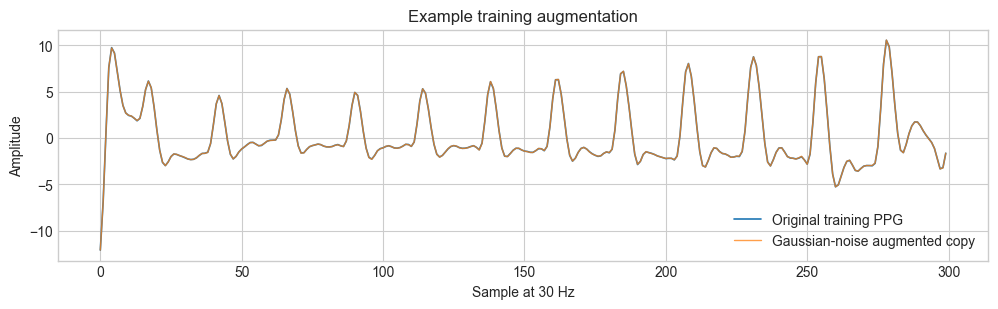

In [159]:
example_index = 0
plt.figure(figsize=(12, 3))
plt.plot(X_train_aug[example_index], label='Original training PPG', linewidth=1.2)
plt.plot(X_train_aug[example_index + len(X_train_raw)], label='Gaussian-noise augmented copy', linewidth=1.0, alpha=0.75)
plt.title('Example training augmentation')
plt.xlabel('Sample at 30 Hz')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


## 8. Normalize PPG Signals

Global normalization is fitted on the augmented training data only. The same training mean and standard deviation are then applied to validation and test signals.


In [160]:
ppg_mean = X_train_aug.mean()
ppg_std = X_train_aug.std()

X_train_norm = ((X_train_aug - ppg_mean) / (ppg_std + 1e-8)).astype('float32')
X_val_norm = ((X_val_raw - ppg_mean) / (ppg_std + 1e-8)).astype('float32')
X_test_norm = ((X_test_raw - ppg_mean) / (ppg_std + 1e-8)).astype('float32')

X_train = X_train_norm[..., np.newaxis]
X_val = X_val_norm[..., np.newaxis]
X_test = X_test_norm[..., np.newaxis]

print('Training normalization mean:', ppg_mean)
print('Training normalization std:', ppg_std)
print('X_train:', X_train.shape, 'y_train:', y_train_aug.shape)
print('X_val:', X_val.shape, 'y_val:', y_val.shape)
print('X_test:', X_test.shape, 'y_test:', y_test.shape)


Training normalization mean: 0.06975039
Training normalization std: 3.0290303
X_train: (136, 300, 1) y_train: (136,)
X_val: (16, 300, 1) y_val: (16,)
X_test: (17, 300, 1) y_test: (17,)


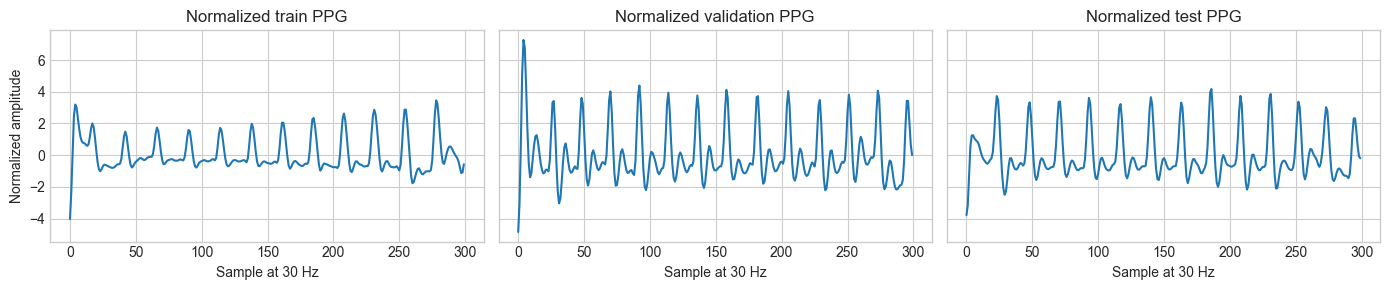

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)

axes[0].plot(X_train[0, :, 0])
axes[0].set_title('Normalized train PPG')

axes[1].plot(X_val[0, :, 0])
axes[1].set_title('Normalized validation PPG')

axes[2].plot(X_test[0, :, 0])
axes[2].set_title('Normalized test PPG')

for ax in axes:
    ax.set_xlabel('Sample at 30 Hz')
axes[0].set_ylabel('Normalized amplitude')
plt.tight_layout()
plt.show()


## 9. Shuffle Training Data and Create PyTorch Loaders


In [162]:
def shuffle_arrays(X, y, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(len(X))
    return X[indices], y[indices]

X_train, y_train_model = shuffle_arrays(X_train, y_train_aug)
y_val_model = y_val
y_test_model = y_test


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False):
    X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train_model, shuffle=True)
val_loader = make_loader(X_val, y_val_model, shuffle=False)
test_loader = make_loader(X_test, y_test_model, shuffle=False)

print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Test batches:', len(test_loader))


Train batches: 17
Validation batches: 2
Test batches: 3


## 10. Model 1: Basic 1D CNN


In [163]:
class BasicPPGCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.regressor(x)

model1 = BasicPPGCNN().to(device)
model1


BasicPPGCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_fea

## 11. Train Model 1

The training loop prints the training and validation MSE for every epoch.


In [164]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.set_grad_enabled(is_training):
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            prediction = model(batch_X)
            loss = criterion(prediction, batch_y)

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_X.size(0)
            total_count += batch_X.size(0)

    return total_loss / total_count

criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model1.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

best_val_loss = np.inf
best_model_state = None
patience_counter = 0
history = []

print('Epoch | Train MAE | Validation MAE')
print('-' * 36)

for epoch in range(1, EPOCHS + 1):
    train_mae = run_epoch(model1, train_loader, criterion, optimizer)
    val_mae = run_epoch(model1, val_loader, criterion)

    history.append({'epoch': epoch, 'train_mae': train_mae, 'val_mae': val_mae})
    print(f'{epoch:03d} | {train_mae:.4f} | {val_mae:.4f}')

    if val_mae < best_val_loss:
        best_val_loss = val_mae
        best_model_state = {key: value.detach().cpu().clone() for key, value in model1.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}. Best validation MSE: {best_val_loss:.4f}')
        break

model1.load_state_dict(best_model_state)
history = pd.DataFrame(history)
history.tail()


Epoch | Train MAE | Validation MAE
------------------------------------
001 | 114.0702 | 109.2949
002 | 113.0515 | 107.6274
003 | 111.4049 | 105.2770
004 | 108.8220 | 102.2731
005 | 105.0333 | 97.3661
006 | 99.6949 | 91.9892
007 | 92.6350 | 83.5536
008 | 83.3703 | 72.3099
009 | 71.7163 | 57.8458
010 | 58.2909 | 42.9717
011 | 41.2226 | 27.4961
012 | 22.9455 | 14.4469
013 | 14.5796 | 14.7693
014 | 15.5029 | 15.5882
015 | 14.0193 | 11.4246
016 | 12.9101 | 12.0651
017 | 14.0136 | 12.0383
018 | 12.4423 | 12.6253
019 | 13.5924 | 14.8731
020 | 13.9440 | 13.5403
021 | 12.6744 | 11.6748
022 | 13.3196 | 11.6053
023 | 13.5083 | 12.1757
024 | 11.9011 | 15.4225
025 | 12.3369 | 12.5331
026 | 11.6460 | 12.0238
027 | 12.1222 | 12.4874
028 | 12.5667 | 13.4913
029 | 11.7992 | 12.3635
030 | 12.3836 | 12.4267
031 | 13.8106 | 13.4932
032 | 11.7524 | 14.9616
033 | 11.6638 | 14.2783
034 | 10.9159 | 16.5938
035 | 12.2035 | 18.9496
036 | 11.3907 | 13.3748
037 | 12.0622 | 12.8577
038 | 11.1611 | 13.9019
039 | 1

,epoch,train_mae,val_mae
35,36,11.390725,13.374779
36,37,12.062207,12.857666
37,38,11.161116,13.901852
38,39,10.727770,13.349261
39,40,12.078880,15.556506


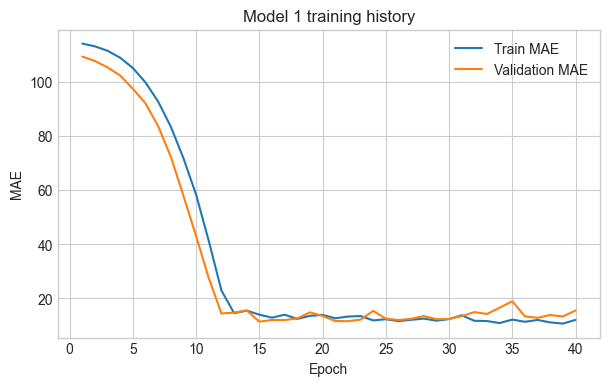

In [165]:
plt.figure(figsize=(7, 4))
plt.plot(history['epoch'], history['train_mae'], label='Train MAE')
plt.plot(history['epoch'], history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model 1 training history')
plt.legend()
plt.show()


## 12. Test Predictions and Regression Metrics

Metrics reported on the unseen test set: **MAE, RMSE, MAPE, R²** (MSE removed).


In [166]:
def predict_model(model, loader):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_pred = model(batch_X).cpu().numpy().reshape(-1)
            predictions.append(batch_pred)
            actuals.append(batch_y.numpy().reshape(-1))

    return np.concatenate(actuals), np.concatenate(predictions)


def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype='float64')
    predicted = np.asarray(predicted, dtype='float64')
    error = actual - predicted

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / actual)) * 100
    r2 = r2_score(actual, predicted)

    return {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2}


actual_test, predicted_test = predict_model(model1, test_loader)
actual_val, predicted_val = predict_model(model1, val_loader)

m1_val_metrics = calculate_metrics(actual_val, predicted_val)
m1_test_metrics = calculate_metrics(actual_test, predicted_test)

model1_metrics_table = pd.DataFrame(
    [m1_val_metrics, m1_test_metrics],
    index=['Model 1 — Basic CNN (Validation)', 'Model 1 — Basic CNN (Test)']
)
model1_metrics_table


,MAE,RMSE,MAPE (%),R²
Model 1 — Basic CNN (Validation),11.424594,14.163554,10.391690,-0.172949
Model 1 — Basic CNN (Test),19.292080,25.212018,14.754394,-0.274750


In [167]:
prediction_table = pd.DataFrame({
    'Actual_Glucose': actual_test,
    'Predicted_Glucose': predicted_test,
    'Absolute_Error': np.abs(actual_test - predicted_test),
})

prediction_table.sort_values('Absolute_Error', ascending=False).head(10)


,Actual_Glucose,Predicted_Glucose,Absolute_Error
16,183.0,111.972733,71.027267
10,146.0,110.373352,35.626648
5,134.0,102.594666,31.405334
4,130.0,101.619263,28.380737
13,130.0,104.015396,25.984604
15,136.0,116.240746,19.759254
0,99.0,117.472488,18.472488
12,103.0,120.488098,17.488098
6,136.0,119.883110,16.116890
11,94.0,109.525787,15.525787


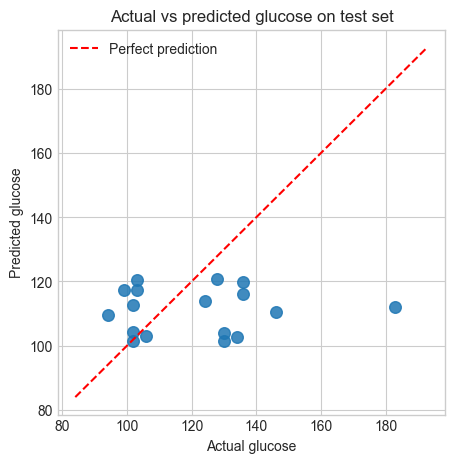

In [168]:
plt.figure(figsize=(5, 5))
plt.scatter(actual_test, predicted_test, s=70, alpha=0.85)

min_value = min(actual_test.min(), predicted_test.min()) - 10
max_value = max(actual_test.max(), predicted_test.max()) + 10
plt.plot([min_value, max_value], [min_value, max_value], 'r--', label='Perfect prediction')

plt.xlabel('Actual glucose')
plt.ylabel('Predicted glucose')
plt.title('Actual vs predicted glucose on test set')
plt.legend()
plt.show()


## 13. Clarke Error Grid


In [169]:
def clarke_zone(actual, predicted):
    actual = float(actual)
    predicted = float(predicted)

    if actual <= 70:
        if predicted <= 70:
            return 'A'
    else:
        if abs(predicted - actual) <= 0.20 * actual:
            return 'A'

    if (actual < 70 and predicted > 180) or (actual > 180 and predicted < 70):
        return 'E'

    if (70 <= actual <= 290 and predicted >= actual + 110) or (130 <= actual <= 180 and predicted <= (7 / 5) * actual - 182):
        return 'C'

    if (actual >= 240 and 70 <= predicted <= 180) or (actual <= 70 and 70 <= predicted <= 180):
        return 'D'

    return 'B'

zones = [clarke_zone(a, p) for a, p in zip(actual_test, predicted_test)]
clarke_counts = pd.Series(zones).value_counts().reindex(list('ABCDE'), fill_value=0)
clarke_percent = (clarke_counts / clarke_counts.sum() * 100).round(2)
clarke_table = pd.DataFrame({'Count': clarke_counts, 'Percent': clarke_percent})
clarke_table


,Count,Percent
A,13,76.47
B,4,23.53
C,0,0.00
D,0,0.00
E,0,0.00


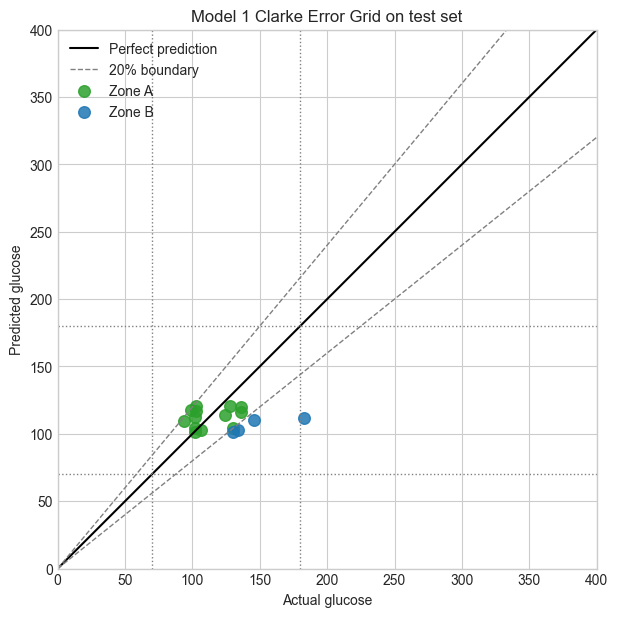

In [170]:
def plot_clarke_error_grid(actual, predicted):
    actual = np.asarray(actual, dtype='float64')
    predicted = np.asarray(predicted, dtype='float64')
    zones = np.array([clarke_zone(a, p) for a, p in zip(actual, predicted)])

    max_value = max(400, actual.max() + 30, predicted.max() + 30)
    grid = np.linspace(0, max_value, 300)

    colors = {
        'A': '#2ca02c',
        'B': '#1f77b4',
        'C': '#ff7f0e',
        'D': '#9467bd',
        'E': '#d62728',
    }

    plt.figure(figsize=(7, 7))
    plt.plot(grid, grid, color='black', linewidth=1.5, label='Perfect prediction')
    plt.plot(grid, 1.2 * grid, color='gray', linestyle='--', linewidth=1, label='20% boundary')
    plt.plot(grid, 0.8 * grid, color='gray', linestyle='--', linewidth=1)
    plt.axhline(70, color='gray', linestyle=':', linewidth=1)
    plt.axvline(70, color='gray', linestyle=':', linewidth=1)
    plt.axhline(180, color='gray', linestyle=':', linewidth=1)
    plt.axvline(180, color='gray', linestyle=':', linewidth=1)

    for zone in list('ABCDE'):
        mask = zones == zone
        if mask.any():
            plt.scatter(actual[mask], predicted[mask], s=70, alpha=0.85, color=colors[zone], label=f'Zone {zone}')

    plt.xlim(0, max_value)
    plt.ylim(0, max_value)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('Actual glucose')
    plt.ylabel('Predicted glucose')
    plt.title('Model 1 Clarke Error Grid on test set')
    plt.legend(loc='upper left')
    plt.show()

plot_clarke_error_grid(actual_test, predicted_test)


## 14. Model 2: Hybrid CNN-GRU

Architecture following the proposed hybrid design:
- **Branch 1 — CNN (large kernel):** captures slow PPG envelope features using kernel sizes 15 and 7.
- **Branch 2 — CNN (small kernel):** captures local pulse morphology using kernel sizes 5 and 3.
- **Branch 3 — GRU (2 layers):** models the sequential dynamics of the 10-second PPG waveform.

Each branch projects to a 64-dim embedding. The three embeddings are concatenated and passed through a regression head to predict glucose.


In [171]:
class HybridCNNGRU(nn.Module):
    """
    Three parallel branches fed the same normalized PPG window:
      Branch 1 — CNN with large kernels (slow envelope / DC trends)
      Branch 2 — CNN with small kernels (local pulse morphology)
      Branch 3 — GRU (sequential temporal dynamics)
    All three FC embeddings are concatenated then passed to the regression head.
    """
    def __init__(self, embed_dim=64, gru_hidden=64, dropout=0.25):
        super().__init__()

        # Branch 1: large receptive-field CNN
        self.cnn1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.fc1 = nn.Sequential(nn.Linear(64, embed_dim), nn.ReLU())

        # Branch 2: small receptive-field CNN
        self.cnn2 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.fc2 = nn.Sequential(nn.Linear(64, embed_dim), nn.ReLU())

        # Branch 3: GRU
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=gru_hidden,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
        )
        self.fc3 = nn.Sequential(nn.Linear(gru_hidden, embed_dim), nn.ReLU())

        # Concatenate all three embeddings → regression head
        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 3, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, 1),
        )

    def forward(self, x):
        # x: (batch, 1, seq_len) — channels first from DataLoader
        branch1 = self.fc1(self.cnn1(x))
        branch2 = self.fc2(self.cnn2(x))

        # GRU expects (batch, seq_len, input_size)
        x_seq = x.permute(0, 2, 1)       # (batch, seq_len, 1)
        _, h_n = self.gru(x_seq)          # h_n: (num_layers, batch, gru_hidden)
        branch3 = self.fc3(h_n[-1])       # last GRU layer hidden state: (batch, gru_hidden)

        combined = torch.cat([branch1, branch2, branch3], dim=1)  # (batch, embed_dim * 3)
        return self.regressor(combined)


model2 = HybridCNNGRU().to(device)
model2


HybridCNNGRU(
  (cnn1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): AdaptiveAvgPool1d(output_size=1)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc1): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
  (cnn2): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(

## 15. Train Model 2

Uses the same `run_epoch` function, `criterion` (MSELoss), and early stopping logic as Model 1.


In [172]:
MODEL2_EPOCHS = 150
MODEL2_LR = 1e-3
MODEL2_WEIGHT_DECAY = 1e-4
MODEL2_PATIENCE = 25

optimizer2 = torch.optim.AdamW(model2.parameters(), lr=MODEL2_LR, weight_decay=MODEL2_WEIGHT_DECAY)

best_val_loss2 = np.inf
best_model2_state = None
patience_counter2 = 0
history_model2 = []

print('Epoch | Train MAE | Validation MAE')
print('-' * 36)

for epoch in range(1, MODEL2_EPOCHS + 1):
    train_mae2 = run_epoch(model2, train_loader, criterion, optimizer2)
    val_mae2 = run_epoch(model2, val_loader, criterion)

    history_model2.append({'epoch': epoch, 'train_mae': train_mae2, 'val_mae': val_mae2})
    print(f'{epoch:03d} | {train_mae2:.4f} | {val_mae2:.4f}')

    if val_mae2 < best_val_loss2:
        best_val_loss2 = val_mae2
        best_model2_state = {k: v.detach().cpu().clone() for k, v in model2.state_dict().items()}
        patience_counter2 = 0
    else:
        patience_counter2 += 1

    if patience_counter2 >= MODEL2_PATIENCE:
        print(f'Early stopping at epoch {epoch}. Best validation MAE: {best_val_loss2:.4f}')
        break

model2.load_state_dict(best_model2_state)
history_model2 = pd.DataFrame(history_model2)
history_model2.tail()


Epoch | Train MAE | Validation MAE
------------------------------------
001 | 113.7515 | 107.7306
002 | 107.0198 | 91.2112
003 | 82.2918 | 45.6958
004 | 30.5935 | 20.4436
005 | 15.8254 | 14.2709
006 | 14.8737 | 15.9439
007 | 13.3942 | 11.5068
008 | 14.0807 | 11.6775
009 | 13.7199 | 14.1510
010 | 13.5299 | 10.6579
011 | 14.5146 | 14.6758
012 | 13.6758 | 14.2301
013 | 12.7855 | 13.8795
014 | 12.7778 | 11.9425
015 | 13.0666 | 14.5156
016 | 14.2261 | 14.8314
017 | 12.6955 | 11.7439
018 | 13.9031 | 19.1247
019 | 13.0988 | 13.4624
020 | 12.2412 | 11.6494
021 | 13.2800 | 15.3667
022 | 12.2522 | 12.3040
023 | 13.4511 | 12.4986
024 | 12.3774 | 14.4990
025 | 13.1157 | 14.7973
026 | 13.4579 | 13.7374
027 | 12.8796 | 13.0668
028 | 12.5302 | 13.1004
029 | 12.3156 | 10.9699
030 | 12.1349 | 12.0111
031 | 13.5998 | 15.4495
032 | 11.6699 | 12.9919
033 | 12.6852 | 19.9255
034 | 13.3980 | 15.1127
035 | 12.9285 | 17.7272
Early stopping at epoch 35. Best validation MAE: 10.6579


,epoch,train_mae,val_mae
30,31,13.599827,15.449525
31,32,11.669895,12.991900
32,33,12.685239,19.925482
33,34,13.398020,15.112654
34,35,12.928470,17.727250


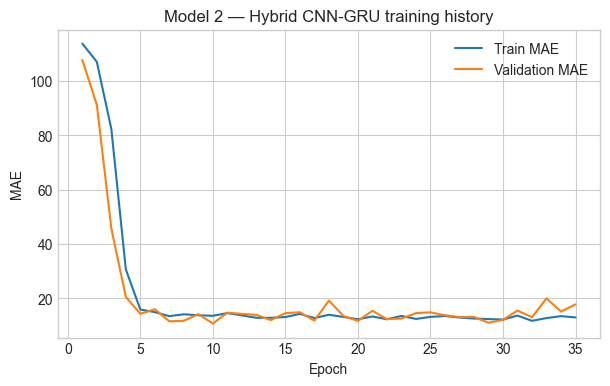

In [173]:
plt.figure(figsize=(7, 4))
plt.plot(history_model2['epoch'], history_model2['train_mae'], label='Train MAE')
plt.plot(history_model2['epoch'], history_model2['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model 2 — Hybrid CNN-GRU training history')
plt.legend()
plt.show()


## 16. Model 2 Test Predictions and Metrics

Same metrics as Model 1: MSE, RMSE, MAE, MAPE on validation and test sets.


In [174]:
model2_actual_test, model2_predicted_test = predict_model(model2, test_loader)
model2_actual_val, model2_predicted_val = predict_model(model2, val_loader)

model2_test_metrics = calculate_metrics(model2_actual_test, model2_predicted_test)
model2_val_metrics = calculate_metrics(model2_actual_val, model2_predicted_val)

model2_metrics_table = pd.DataFrame(
    [model2_val_metrics, model2_test_metrics],
    index=['Model 2 — Hybrid CNN-GRU (Validation)', 'Model 2 — Hybrid CNN-GRU (Test)']
)
model2_metrics_table


,MAE,RMSE,MAPE (%),R²
Model 2 — Hybrid CNN-GRU (Validation),10.657877,13.733871,9.644142,-0.102860
Model 2 — Hybrid CNN-GRU (Test),18.766856,25.006558,14.152545,-0.254058


In [175]:
model2_pred_table = pd.DataFrame({
    'Actual_Glucose': model2_actual_test,
    'Predicted_Glucose': model2_predicted_test,
    'Absolute_Error': np.abs(model2_actual_test - model2_predicted_test),
})
model2_pred_table.sort_values('Absolute_Error', ascending=False).head(10)


,Actual_Glucose,Predicted_Glucose,Absolute_Error
16,183.0,107.388016,75.611984
10,146.0,113.396324,32.603676
15,136.0,109.017349,26.982651
5,134.0,107.176498,26.823502
4,130.0,107.582336,22.417664
8,124.0,104.995224,19.004776
6,136.0,117.656967,18.343033
13,130.0,112.930099,17.069901
0,99.0,114.715538,15.715538
2,103.0,117.925552,14.925552


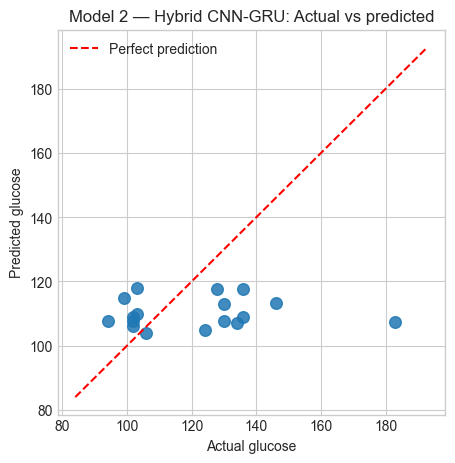

In [176]:
min_val = min(float(model2_actual_test.min()), float(model2_predicted_test.min())) - 10
max_val = max(float(model2_actual_test.max()), float(model2_predicted_test.max())) + 10

plt.figure(figsize=(5, 5))
plt.scatter(model2_actual_test, model2_predicted_test, s=70, alpha=0.85)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual glucose')
plt.ylabel('Predicted glucose')
plt.title('Model 2 — Hybrid CNN-GRU: Actual vs predicted')
plt.legend()
plt.show()


## 17. Model 2 Clarke Error Grid


Clarke Error Grid zone distribution — Model 2


,Count,Percent
A,14,82.35
B,3,17.65
C,0,0.00
D,0,0.00
E,0,0.00


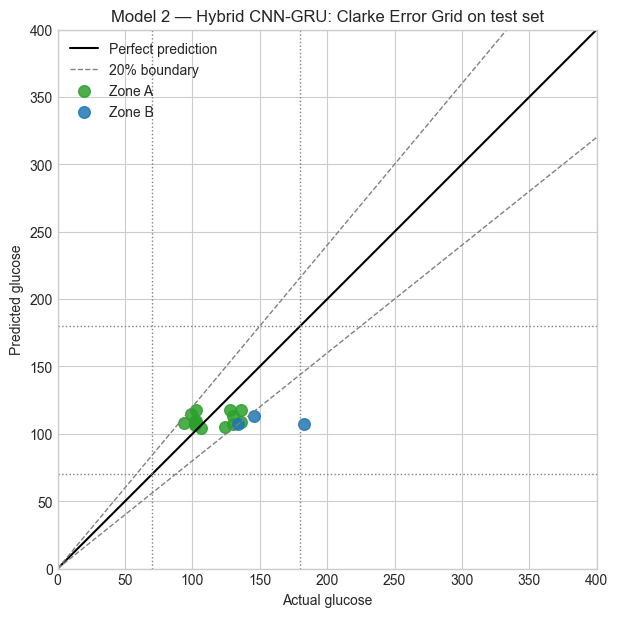

In [177]:
model2_zones = [clarke_zone(a, p) for a, p in zip(model2_actual_test, model2_predicted_test)]
model2_clarke_counts = pd.Series(model2_zones).value_counts().reindex(list('ABCDE'), fill_value=0)
model2_clarke_percent = (model2_clarke_counts / model2_clarke_counts.sum() * 100).round(2)
model2_clarke_table = pd.DataFrame({'Count': model2_clarke_counts, 'Percent': model2_clarke_percent})
print('Clarke Error Grid zone distribution — Model 2')
display(model2_clarke_table)

model2_zones_arr = np.array(model2_zones)
colors = {'A': '#2ca02c', 'B': '#1f77b4', 'C': '#ff7f0e', 'D': '#9467bd', 'E': '#d62728'}

max_value = max(400, float(model2_actual_test.max()) + 30, float(model2_predicted_test.max()) + 30)
grid = np.linspace(0, max_value, 300)

plt.figure(figsize=(7, 7))
plt.plot(grid, grid, color='black', linewidth=1.5, label='Perfect prediction')
plt.plot(grid, 1.2 * grid, color='gray', linestyle='--', linewidth=1, label='20% boundary')
plt.plot(grid, 0.8 * grid, color='gray', linestyle='--', linewidth=1)
plt.axhline(70, color='gray', linestyle=':', linewidth=1)
plt.axvline(70, color='gray', linestyle=':', linewidth=1)
plt.axhline(180, color='gray', linestyle=':', linewidth=1)
plt.axvline(180, color='gray', linestyle=':', linewidth=1)

for zone in list('ABCDE'):
    mask = model2_zones_arr == zone
    if mask.any():
        plt.scatter(model2_actual_test[mask], model2_predicted_test[mask],
                    s=70, alpha=0.85, color=colors[zone], label=f'Zone {zone}')

plt.xlim(0, max_value)
plt.ylim(0, max_value)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Actual glucose')
plt.ylabel('Predicted glucose')
plt.title('Model 2 — Hybrid CNN-GRU: Clarke Error Grid on test set')
plt.legend(loc='upper left')
plt.show()


## 18. Model 3: CNN + Bidirectional GRU + Self-Attention

Architecture from the proposed design:

| Stage | Details | Output shape |
|---|---|---|
| Input | Normalized PPG | (batch, 1, 300) |
| Conv1d block 1 (k=7, 32 filters) + BN + ReLU + MaxPool(2) | Local waveform edges | (batch, 32, 150) |
| Conv1d block 2 (k=5, 64 filters) + BN + ReLU + MaxPool(2) | Peaks, notches, slopes | (batch, 64, 75) |
| Conv1d block 3 (k=3, 128 filters) + BN + ReLU + MaxPool(2) | Higher-level patterns | (batch, 128, 37) |
| Dropout(0.3) | Regularize CNN features | (batch, 128, 37) |
| Bidirectional GRU (64 units × 2 layers) | Temporal context both directions | (batch, 37, 128) |
| Self-attention (additive) | Weighted sum over timesteps | (batch, 128) |
| Dense(64) + ReLU + Dropout(0.2) | Regression projection | (batch, 64) |
| Dense(1) | Glucose output | (batch, 1) |


In [178]:
class SelfAttention1D(nn.Module):
    """Additive self-attention that produces a weighted sum over time steps."""
    def __init__(self, embed_dim):
        super().__init__()
        self.score = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len, embed_dim)
        scores = self.score(x)                  # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)  # (batch, seq_len, 1)
        return (x * weights).sum(dim=1)         # (batch, embed_dim)


class CNNBiGRUAttention(nn.Module):
    """
    Sequential pipeline:
      CNN feature extractor (3 blocks) → Dropout(0.3)
      → Bidirectional GRU (64 units × 2 layers) → (batch, seq, 128)
      → Self-attention weighted sum → (batch, 128)
      → Dense(64) + ReLU + Dropout(0.2) → Dense(1)
    """
    def __init__(self, gru_hidden=64, dropout_cnn=0.3, dropout_fc=0.2):
        super().__init__()

        # 3-block CNN feature extractor (channels first)
        self.cnn = nn.Sequential(
            # Block 1: captures local waveform edges
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 2: detects peaks, notches, slopes
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 3: higher-level pattern combinations
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Dropout(dropout_cnn),
        )

        # Bidirectional GRU: input_size=128 (CNN output channels)
        # bidirectional → hidden_size * 2 = 128 per time step
        self.bigru = nn.GRU(
            input_size=128,
            hidden_size=gru_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.25,
        )

        self.attention = SelfAttention1D(embed_dim=gru_hidden * 2)  # 128

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(gru_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout_fc),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (batch, 1, seq_len) — channels first
        cnn_out = self.cnn(x)              # (batch, 128, seq_len // 8)

        # GRU needs (batch, seq_len, features)
        gru_in = cnn_out.permute(0, 2, 1)          # (batch, seq_len//8, 128)
        gru_out, _ = self.bigru(gru_in)             # (batch, seq_len//8, 128)

        context = self.attention(gru_out)            # (batch, 128)
        return self.regressor(context)


model3 = CNNBiGRUAttention().to(device)
model3


CNNBiGRUAttention(
  (cnn): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.3, inplace=False)
  )
  (bigru): GRU(128, 64, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (attention): SelfAttention1D(
    (score): Line

## 19. Train Model 3

Uses the same `run_epoch`, `criterion` (MSELoss), and early stopping logic as Models 1 and 2.


In [179]:
MODEL3_EPOCHS = 150
MODEL3_LR = 1e-3
MODEL3_WEIGHT_DECAY = 1e-4
MODEL3_PATIENCE = 25

optimizer3 = torch.optim.AdamW(model3.parameters(), lr=MODEL3_LR, weight_decay=MODEL3_WEIGHT_DECAY)

best_val_loss3 = np.inf
best_model3_state = None
patience_counter3 = 0
history_model3 = []

print('Epoch | Train MAE | Validation MAE')
print('-' * 36)

for epoch in range(1, MODEL3_EPOCHS + 1):
    train_mae3 = run_epoch(model3, train_loader, criterion, optimizer3)
    val_mae3 = run_epoch(model3, val_loader, criterion)

    history_model3.append({'epoch': epoch, 'train_mae': train_mae3, 'val_mae': val_mae3})
    print(f'{epoch:03d} | {train_mae3:.4f} | {val_mae3:.4f}')

    if val_mae3 < best_val_loss3:
        best_val_loss3 = val_mae3
        best_model3_state = {k: v.detach().cpu().clone() for k, v in model3.state_dict().items()}
        patience_counter3 = 0
    else:
        patience_counter3 += 1

    if patience_counter3 >= MODEL3_PATIENCE:
        print(f'Early stopping at epoch {epoch}. Best validation MAE: {best_val_loss3:.4f}')
        break

model3.load_state_dict(best_model3_state)
history_model3 = pd.DataFrame(history_model3)
history_model3.tail()


Epoch | Train MAE | Validation MAE
------------------------------------
001 | 112.0508 | 104.0511
002 | 105.0220 | 95.2161
003 | 94.2070 | 82.3651
004 | 78.9002 | 64.8397
005 | 58.9239 | 42.1713
006 | 35.0710 | 15.7709
007 | 15.9587 | 11.6891
008 | 15.7015 | 11.1176
009 | 15.2949 | 10.3128
010 | 14.0174 | 10.4530
011 | 15.9607 | 10.3129
012 | 15.3706 | 10.3129
013 | 15.3440 | 11.5443
014 | 15.7394 | 10.9129
015 | 15.5836 | 10.4047
016 | 16.2548 | 10.3143
017 | 16.3817 | 10.8674
018 | 15.8071 | 10.4229
019 | 15.4376 | 10.3133
020 | 14.2942 | 10.3195
021 | 14.3596 | 9.6331
022 | 14.3777 | 10.7816
023 | 15.5569 | 10.4234
024 | 15.8338 | 10.2862
025 | 15.5895 | 10.6549
026 | 16.3606 | 10.3807
027 | 14.1668 | 11.1942
028 | 16.1331 | 10.2120
029 | 14.4063 | 10.8085
030 | 14.9355 | 10.5937
031 | 15.3514 | 11.0494
032 | 14.5473 | 11.7048
033 | 13.2379 | 11.1273
034 | 14.2147 | 11.5227
035 | 13.8885 | 11.9970
036 | 14.3900 | 11.8517
037 | 14.7483 | 11.1907
038 | 15.9553 | 10.6026
039 | 13.5363 

,epoch,train_mae,val_mae
41,42,13.707466,12.995491
42,43,13.650302,12.010057
43,44,14.173012,11.860766
44,45,14.652210,13.093604
45,46,14.069798,13.289598


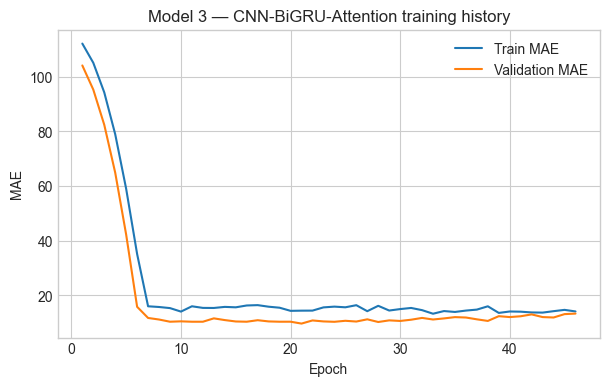

In [180]:
plt.figure(figsize=(7, 4))
plt.plot(history_model3['epoch'], history_model3['train_mae'], label='Train MAE')
plt.plot(history_model3['epoch'], history_model3['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model 3 — CNN-BiGRU-Attention training history')
plt.legend()
plt.show()


## 20. Model 3 Predictions and Metrics

Same metrics as Models 1 and 2: MAE, RMSE, MAPE (%), R² on validation and test sets.


In [181]:
model3_actual_test, model3_predicted_test = predict_model(model3, test_loader)
model3_actual_val, model3_predicted_val = predict_model(model3, val_loader)

m3_val_metrics = calculate_metrics(model3_actual_val, model3_predicted_val)
m3_test_metrics = calculate_metrics(model3_actual_test, model3_predicted_test)

model3_metrics_table = pd.DataFrame(
    [m3_val_metrics, m3_test_metrics],
    index=['Model 3 — CNN-BiGRU-Attention (Validation)', 'Model 3 — CNN-BiGRU-Attention (Test)']
)
model3_metrics_table


,MAE,RMSE,MAPE (%),R²
Model 3 — CNN-BiGRU-Attention (Validation),9.633130,12.515907,8.835203,0.084077
Model 3 — CNN-BiGRU-Attention (Test),19.596373,24.912854,14.925702,-0.244677


In [182]:
model3_pred_table = pd.DataFrame({
    'Actual_Glucose': model3_actual_test,
    'Predicted_Glucose': model3_predicted_test,
    'Absolute_Error': np.abs(model3_actual_test - model3_predicted_test),
})
model3_pred_table.sort_values('Absolute_Error', ascending=False).head(10)


,Actual_Glucose,Predicted_Glucose,Absolute_Error
16,183.0,110.622429,72.377571
10,146.0,111.655800,34.344200
15,136.0,110.921173,25.078827
6,136.0,111.488213,24.511787
8,124.0,99.799042,24.200958
5,134.0,111.605949,22.394051
13,130.0,111.162483,18.837517
4,130.0,111.282173,18.717827
11,94.0,111.645981,17.645981
3,128.0,111.668167,16.331833


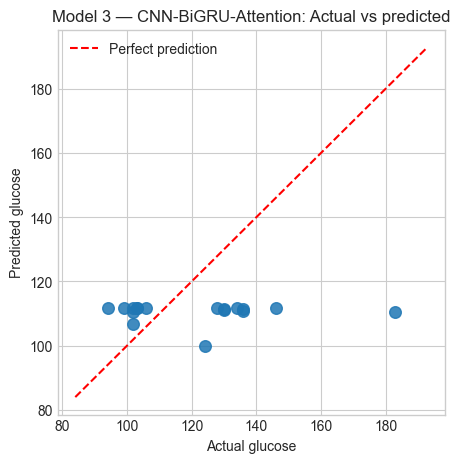

In [183]:
min_val3 = min(float(model3_actual_test.min()), float(model3_predicted_test.min())) - 10
max_val3 = max(float(model3_actual_test.max()), float(model3_predicted_test.max())) + 10

plt.figure(figsize=(5, 5))
plt.scatter(model3_actual_test, model3_predicted_test, s=70, alpha=0.85)
plt.plot([min_val3, max_val3], [min_val3, max_val3], 'r--', label='Perfect prediction')
plt.xlabel('Actual glucose')
plt.ylabel('Predicted glucose')
plt.title('Model 3 — CNN-BiGRU-Attention: Actual vs predicted')
plt.legend()
plt.show()


## 21. Model 3 Clarke Error Grid


Clarke Error Grid zone distribution — Model 3


,Count,Percent
A,15,88.24
B,2,11.76
C,0,0.00
D,0,0.00
E,0,0.00


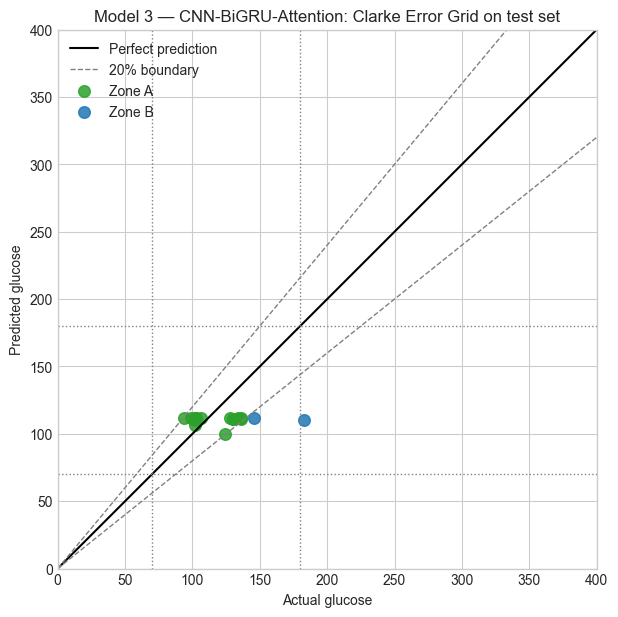

In [184]:
model3_zones = [clarke_zone(a, p) for a, p in zip(model3_actual_test, model3_predicted_test)]
model3_clarke_counts = pd.Series(model3_zones).value_counts().reindex(list('ABCDE'), fill_value=0)
model3_clarke_percent = (model3_clarke_counts / model3_clarke_counts.sum() * 100).round(2)
model3_clarke_table = pd.DataFrame({'Count': model3_clarke_counts, 'Percent': model3_clarke_percent})
print('Clarke Error Grid zone distribution — Model 3')
display(model3_clarke_table)

model3_zones_arr = np.array(model3_zones)
colors_ceg = {'A': '#2ca02c', 'B': '#1f77b4', 'C': '#ff7f0e', 'D': '#9467bd', 'E': '#d62728'}
max_val_ceg = max(400, float(model3_actual_test.max()) + 30, float(model3_predicted_test.max()) + 30)
grid_ceg = np.linspace(0, max_val_ceg, 300)

plt.figure(figsize=(7, 7))
plt.plot(grid_ceg, grid_ceg, color='black', linewidth=1.5, label='Perfect prediction')
plt.plot(grid_ceg, 1.2 * grid_ceg, color='gray', linestyle='--', linewidth=1, label='20% boundary')
plt.plot(grid_ceg, 0.8 * grid_ceg, color='gray', linestyle='--', linewidth=1)
plt.axhline(70, color='gray', linestyle=':', linewidth=1)
plt.axvline(70, color='gray', linestyle=':', linewidth=1)
plt.axhline(180, color='gray', linestyle=':', linewidth=1)
plt.axvline(180, color='gray', linestyle=':', linewidth=1)

for zone in list('ABCDE'):
    mask = model3_zones_arr == zone
    if mask.any():
        plt.scatter(model3_actual_test[mask], model3_predicted_test[mask],
                    s=70, alpha=0.85, color=colors_ceg[zone], label=f'Zone {zone}')

plt.xlim(0, max_val_ceg)
plt.ylim(0, max_val_ceg)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Actual glucose')
plt.ylabel('Predicted glucose')
plt.title('Model 3 — CNN-BiGRU-Attention: Clarke Error Grid on test set')
plt.legend(loc='upper left')
plt.show()


## 22. 10-Fold Cross-Validation — All 3 Models

Each fold trains each model from scratch on the fold's training subjects (with augmentation and per-fold normalization), then evaluates on the held-out test subjects. `GroupKFold` ensures no subject appears in both train and test within any fold.

- **`CV_EPOCHS = 60`** — fixed epochs per fold to keep total runtime manageable (3 models × 10 folds × 60 epochs = 1800 epoch runs).
- Normalization is re-fitted on each fold's augmented training data so there is no leakage.


In [185]:
CV_FOLDS = 10
CV_EPOCHS = 60

def run_cv_fold(model_factory, X_all, y_all, train_idx, test_idx):
    X_tr = X_all[train_idx]
    y_tr = y_all[train_idx]
    X_te = X_all[test_idx]
    y_te = y_all[test_idx]

    # Augment only the fold's training data
    X_aug, y_aug = augment_with_gaussian_noise(X_tr, y_tr, noise_stds=NOISE_STDS, random_state=RANDOM_STATE)

    # Normalize using fold training statistics only
    fold_mean = X_aug.mean()
    fold_std = X_aug.std() + 1e-8
    X_tr_norm = ((X_aug - fold_mean) / fold_std)[..., np.newaxis].astype('float32')
    X_te_norm = ((X_te - fold_mean) / fold_std)[..., np.newaxis].astype('float32')

    tr_loader = make_loader(X_tr_norm, y_aug, batch_size=BATCH_SIZE, shuffle=True)
    te_loader = make_loader(X_te_norm, y_te, batch_size=BATCH_SIZE, shuffle=False)

    model = model_factory().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    cv_criterion = nn.MSELoss()

    for _ in range(CV_EPOCHS):
        run_epoch(model, tr_loader, cv_criterion, opt)

    actual, predicted = predict_model(model, te_loader)
    return calculate_metrics(actual, predicted)


X_all_cv = np.stack(ppg_records['processed_signal'].to_numpy()).astype('float32')
y_all_cv = ppg_records['glucose'].to_numpy(dtype='float32')
groups_all_cv = ppg_records['subject_id'].to_numpy()

model_factories = {
    'Model 1 — Basic CNN': BasicPPGCNN,
    'Model 2 — Hybrid CNN-GRU': HybridCNNGRU,
    'Model 3 — CNN-BiGRU-Attention': CNNBiGRUAttention,
}

gkf = GroupKFold(n_splits=CV_FOLDS)
all_cv_records = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_all_cv, y_all_cv, groups=groups_all_cv)):
    print(f'Fold {fold_idx + 1}/{CV_FOLDS}  train: {len(train_idx)}  test: {len(test_idx)}')
    for model_name, model_factory in model_factories.items():
        metrics = run_cv_fold(model_factory, X_all_cv, y_all_cv, train_idx, test_idx)
        metrics['Model'] = model_name
        metrics['Fold'] = fold_idx + 1
        all_cv_records.append(metrics)
        print(f'  {model_name} | MAE: {metrics["MAE"]:.2f}  RMSE: {metrics["RMSE"]:.2f}  R²: {metrics["R²"]:.3f}')

cv_df = pd.DataFrame(all_cv_records)
print('\nAll folds complete.')
cv_df.head(10)


Fold 1/10  train: 60  test: 7
  Model 1 — Basic CNN | MAE: 13.85  RMSE: 17.89  R²: -0.349
  Model 2 — Hybrid CNN-GRU | MAE: 20.10  RMSE: 22.23  R²: -1.083
  Model 3 — CNN-BiGRU-Attention | MAE: 12.44  RMSE: 15.16  R²: 0.032
Fold 2/10  train: 60  test: 7
  Model 1 — Basic CNN | MAE: 16.21  RMSE: 18.99  R²: -0.461
  Model 2 — Hybrid CNN-GRU | MAE: 14.65  RMSE: 17.17  R²: -0.195
  Model 3 — CNN-BiGRU-Attention | MAE: 12.53  RMSE: 14.51  R²: 0.147
Fold 3/10  train: 60  test: 7
  Model 1 — Basic CNN | MAE: 19.58  RMSE: 30.51  R²: -0.285
  Model 2 — Hybrid CNN-GRU | MAE: 18.17  RMSE: 21.45  R²: 0.365
  Model 3 — CNN-BiGRU-Attention | MAE: 22.56  RMSE: 34.38  R²: -0.631
Fold 4/10  train: 61  test: 6
  Model 1 — Basic CNN | MAE: 14.10  RMSE: 17.81  R²: -3.086
  Model 2 — Hybrid CNN-GRU | MAE: 12.19  RMSE: 15.26  R²: -1.998
  Model 3 — CNN-BiGRU-Attention | MAE: 27.21  RMSE: 32.58  R²: -12.671
Fold 5/10  train: 61  test: 6
  Model 1 — Basic CNN | MAE: 14.40  RMSE: 17.22  R²: 0.044
  Model 2 — H

,MAE,RMSE,MAPE (%),R²,Model,Fold
0,13.853301,17.887395,11.000097,-0.348528,Model 1 — Basic CNN,1
1,20.099435,22.230426,17.491771,-1.082866,Model 2 — Hybrid CNN-GRU,1
2,12.435107,15.156732,9.856949,0.031774,Model 3 — CNN-BiGRU-Attention,1
3,16.211799,18.990511,15.287486,-0.461166,Model 1 — Basic CNN,2
4,14.647917,17.174494,13.623227,-0.195072,Model 2 — Hybrid CNN-GRU,2
5,12.533994,14.512701,11.829550,0.146659,Model 3 — CNN-BiGRU-Attention,2
6,19.579457,30.510596,14.333502,-0.284538,Model 1 — Basic CNN,3
7,18.167642,21.450056,15.050058,0.365104,Model 2 — Hybrid CNN-GRU,3
8,22.561819,34.377356,16.502364,-0.630761,Model 3 — CNN-BiGRU-Attention,3
9,14.103176,17.814165,13.240947,-3.085980,Model 1 — Basic CNN,4


In [186]:
model_order = ['Model 1 — Basic CNN', 'Model 2 — Hybrid CNN-GRU', 'Model 3 — CNN-BiGRU-Attention']

cv_summary = (
    cv_df.groupby('Model')[['MAE', 'RMSE', 'MAPE (%)', 'R²']]
    .agg(['mean', 'std'])
    .round(3)
    .loc[model_order]
)
print('10-Fold CV Summary (mean ± std across folds)')
cv_summary


10-Fold CV Summary (mean ± std across folds)


MAE            RMSE         MAPE (%)         \
                                 mean     std    mean     std     mean    std   
Model                                                                           
Model 1 — Basic CNN            17.888   5.943  22.264   7.757   15.002  3.505   
Model 2 — Hybrid CNN-GRU       19.592  10.605  24.073  14.518   17.057  9.671   
Model 3 — CNN-BiGRU-Attention  17.317   8.346  21.810  10.597   14.458  6.751   

                                  R²         
                                mean    std  
Model                                        
Model 1 — Basic CNN           -1.227  1.454  
Model 2 — Hybrid CNN-GRU      -3.665  9.232  
Model 3 — CNN-BiGRU-Attention -2.034  4.282

/var/folders/y8/q2s37ndx6tg3lpzp3vp8xk_r0000gn/T/ipykernel_40082/40093757.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_labels, patch_artist=True)
/var/folders/y8/q2s37ndx6tg3lpzp3vp8xk_r0000gn/T/ipykernel_40082/40093757.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_labels, patch_artist=True)
/var/folders/y8/q2s37ndx6tg3lpzp3vp8xk_r0000gn/T/ipykernel_40082/40093757.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_labels, patch_artist=True)
/var/folders/y8/q2s37ndx6tg3lpzp3vp8xk_r0000gn/T/ipykernel_40

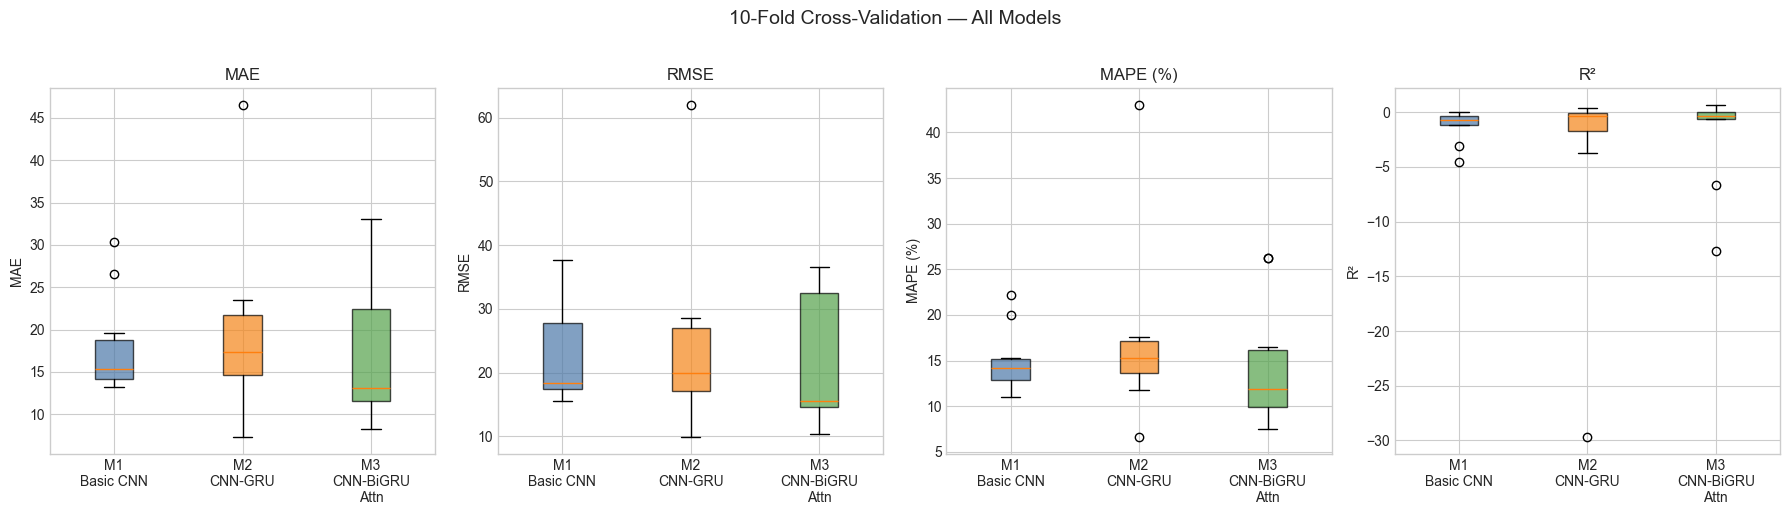

In [187]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_cols = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
model_labels = ['M1\nBasic CNN', 'M2\nCNN-GRU', 'M3\nCNN-BiGRU\nAttn']

for ax, metric in zip(axes, metrics_cols):
    data = [cv_df[cv_df['Model'] == name][metric].values for name in model_order]
    bp = ax.boxplot(data, labels=model_labels, patch_artist=True)
    colors_box = ['#4C78A8', '#F58518', '#54A24B']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)

plt.suptitle('10-Fold Cross-Validation — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
